<a href="https://colab.research.google.com/github/BhagyashreeMohalkar/ADS_Lab_Assignments/blob/main/Loan_Approval_Prediction_Deployement_using_streamlit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q streamlit pyngrok scikit-learn pandas numpy joblib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 38.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 35.1 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import joblib
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [4]:
# Install Kaggle
!pip install -q kaggle

from getpass import getpass
import os

# Enter your Kaggle API token
kaggle_api_key = getpass("🔑 Enter your Kaggle API Key: ")

os.environ["KAGGLE_API_TOKEN"] = kaggle_api_key

print("✅ Kaggle API key configured!")

🔑 Enter your Kaggle API Key: ··········
✅ Kaggle API key configured!


In [5]:
!kaggle datasets list -s "loan approval prediction" | head -10

ref                                                                  title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-------------------------------------------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
architsharma01/loan-approval-prediction-dataset                      Loan-Approval-Prediction-Dataset                         82535  2023-07-16 16:31:20.923000          54836        283                1  
krishnaraj30/finance-loan-approval-prediction-data                   Finance Loan approval Prediction Data                    12824  2023-06-08 16:29:50.153000          11336        114                1  
muhammadmusharraf444/loan-approval-dataset                           Loan Approval Prediction Dataset                        736039  2026-06-03 09:49:27.513000           1306      

In [6]:
!mkdir -p /content/loan_app/dataset

!kaggle datasets download \
    -d architsharma01/loan-approval-prediction-dataset \
    -p /content/loan_app/dataset

print("✅ Dataset downloaded successfully!")

Dataset URL: https://www.kaggle.com/datasets/architsharma01/loan-approval-prediction-dataset
License(s): MIT
100% 80.6k/80.6k [00:00<00:00, 72.6MB/s]

✅ Dataset downloaded successfully!


In [7]:
import zipfile
import glob
import os

zip_files = glob.glob("/content/loan_app/dataset/*.zip")

print("ZIP files found:", zip_files)

for zip_file in zip_files:
    with zipfile.ZipFile(zip_file, "r") as zip_ref:
        zip_ref.extractall("/content/loan_app/dataset")

print("\n✅ Dataset extracted!")

for root, dirs, files in os.walk("/content/loan_app/dataset"):
    for file in files:
        print(os.path.join(root, file))

ZIP files found: ['/content/loan_app/dataset/loan-approval-prediction-dataset.zip']

✅ Dataset extracted!
/content/loan_app/dataset/loan-approval-prediction-dataset.zip
/content/loan_app/dataset/loan_approval_dataset.csv


In [8]:
import pandas as pd
import glob

csv_files = glob.glob(
    "/content/loan_app/dataset/**/*.csv",
    recursive=True
)

print("CSV files found:")
for file in csv_files:
    print(file)

# Load the first CSV
df = pd.read_csv(csv_files[0])

print("\nDataset shape:", df.shape)

display(df.head())

CSV files found:
/content/loan_app/dataset/loan_approval_dataset.csv

Dataset shape: (4269, 13)


,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [9]:
print("===== COLUMNS =====")
print(df.columns.tolist())

print("\n===== DATA TYPES =====")
print(df.dtypes)

print("\n===== MISSING VALUES =====")
print(df.isnull().sum())

print("\n===== DATASET SHAPE =====")
print(df.shape)

===== COLUMNS =====
['loan_id', ' no_of_dependents', ' education', ' self_employed', ' income_annum', ' loan_amount', ' loan_term', ' cibil_score', ' residential_assets_value', ' commercial_assets_value', ' luxury_assets_value', ' bank_asset_value', ' loan_status']

===== DATA TYPES =====
loan_id                       int64
 no_of_dependents             int64
 education                   object
 self_employed               object
 income_annum                 int64
 loan_amount                  int64
 loan_term                    int64
 cibil_score                  int64
 residential_assets_value     int64
 commercial_assets_value      int64
 luxury_assets_value          int64
 bank_asset_value             int64
 loan_status                 object
dtype: object

===== MISSING VALUES =====
loan_id                      0
 no_of_dependents            0
 education                   0
 self_employed               0
 income_annum                0
 loan_amount                 0
 loan_term    

In [10]:
# Remove leading/trailing spaces from column names
df.columns = df.columns.str.strip()

print("Cleaned columns:")
print(df.columns.tolist())


Cleaned columns:
['loan_id', 'no_of_dependents', 'education', 'self_employed', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value', 'loan_status']


In [11]:
df = df.drop("loan_id", axis=1)

print("✅ loan_id removed")
print("New shape:", df.shape)

display(df.head())

✅ loan_id removed
New shape: (4269, 12)


,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [12]:
print("Loan Status Distribution:")
print(df["loan_status"].value_counts())

print("\nPercentage:")
print(df["loan_status"].value_counts(normalize=True) * 100)

Loan Status Distribution:
loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64

Percentage:
loan_status
Approved    62.215976
Rejected    37.784024
Name: proportion, dtype: float64


In [13]:
from sklearn.preprocessing import LabelEncoder

label_encoders = {}

categorical_columns = [
    "education",
    "self_employed",
    "loan_status"
]

for col in categorical_columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

print("✅ Categorical columns encoded!")

display(df.head())


✅ Categorical columns encoded!


,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,0,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,0
1,0,1,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,1
2,3,0,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,1
3,3,0,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,1
4,5,1,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,1


In [14]:
for col, le in label_encoders.items():
    print(f"\n{col}")
    print(dict(zip(le.classes_, le.transform(le.classes_))))


education
{' Graduate': np.int64(0), ' Not Graduate': np.int64(1)}

self_employed
{' No': np.int64(0), ' Yes': np.int64(1)}

loan_status
{' Approved': np.int64(0), ' Rejected': np.int64(1)}


In [15]:
X = df.drop("loan_status", axis=1)
y = df["loan_status"]

print("Features:")
print(X.columns.tolist())

print("\nTarget: loan_status")

print("\nX shape:", X.shape)
print("y shape:", y.shape)

Features:
['no_of_dependents', 'education', 'self_employed', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value']

Target: loan_status

X shape: (4269, 11)
y shape: (4269,)


In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 3415
Testing samples: 854


In [17]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    random_state=42
)

model.fit(X_train, y_train)

print("✅ Random Forest model trained successfully!")

✅ Random Forest model trained successfully!


In [18]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy * 100:.2f}%")

print("\n===== CLASSIFICATION REPORT =====")
print(classification_report(y_test, y_pred))

print("\n===== CONFUSION MATRIX =====")
print(confusion_matrix(y_test, y_pred))

Accuracy: 98.24%

===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       531
           1       0.99      0.97      0.98       323

    accuracy                           0.98       854
   macro avg       0.98      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854


===== CONFUSION MATRIX =====
[[527   4]
 [ 11 312]]


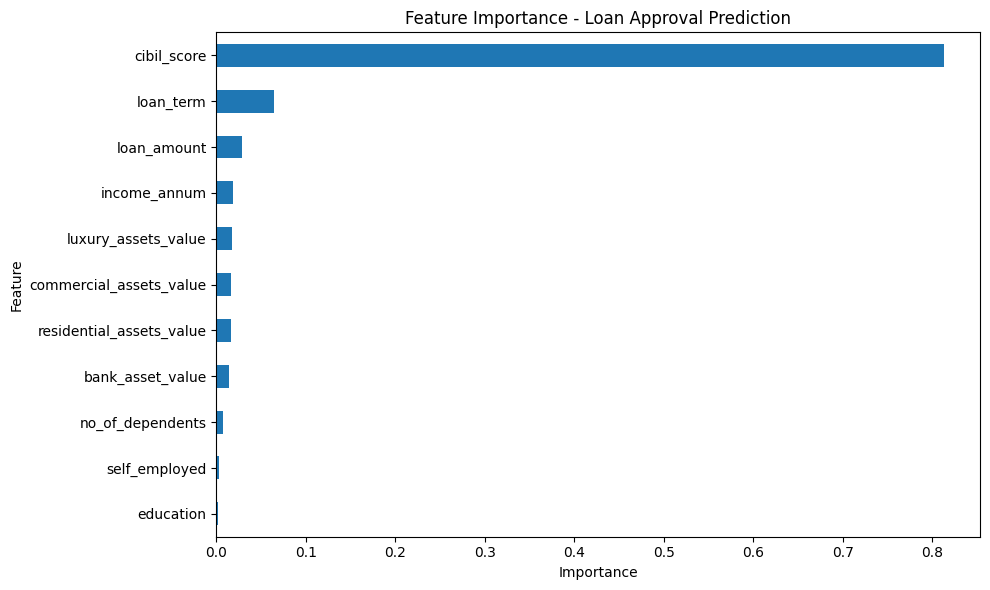

In [19]:
import matplotlib.pyplot as plt

importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
importance.plot(kind="barh")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance - Loan Approval Prediction")
plt.tight_layout()
plt.show()

In [20]:
import joblib
import os

APP_DIR = "/content/loan_app"

os.makedirs(APP_DIR, exist_ok=True)

joblib.dump(model, f"{APP_DIR}/loan_model.pkl")
joblib.dump(label_encoders, f"{APP_DIR}/label_encoders.pkl")
joblib.dump(list(X.columns), f"{APP_DIR}/features.pkl")

print("✅ All model files saved!")

print(f"\n📁 {APP_DIR}/loan_model.pkl")
print(f"📁 {APP_DIR}/label_encoders.pkl")
print(f"📁 {APP_DIR}/features.pkl")

✅ All model files saved!

📁 /content/loan_app/loan_model.pkl
📁 /content/loan_app/label_encoders.pkl
📁 /content/loan_app/features.pkl


In [21]:
%%writefile /content/loan_app/app.py

import streamlit as st
import pandas as pd
import joblib

# ==========================================
# PAGE CONFIGURATION
# ==========================================

st.set_page_config(
    page_title="Loan Approval Predictor",
    page_icon="🏦",
    layout="centered"
)

# ==========================================
# LOAD MODEL
# ==========================================

model = joblib.load("/content/loan_app/loan_model.pkl")
label_encoders = joblib.load("/content/loan_app/label_encoders.pkl")
features = joblib.load("/content/loan_app/features.pkl")

# ==========================================
# TITLE
# ==========================================

st.title("🏦 Loan Approval Prediction System")

st.write(
    "Enter the applicant details below to predict "
    "whether the loan application is likely to be approved."
)

st.divider()

# ==========================================
# INPUT SECTION
# ==========================================

st.subheader("📋 Applicant Details")

no_of_dependents = st.number_input(
    "Number of Dependents",
    min_value=0,
    max_value=10,
    value=2,
    step=1
)

education = st.selectbox(
    "Education",
    ["Graduate", "Not Graduate"]
)

self_employed = st.selectbox(
    "Self Employed",
    ["Yes", "No"]
)

st.subheader("💰 Financial Details")

income_annum = st.number_input(
    "Annual Income",
    min_value=0,
    value=500000,
    step=10000
)

loan_amount = st.number_input(
    "Loan Amount",
    min_value=0,
    value=1000000,
    step=50000
)

loan_term = st.number_input(
    "Loan Term (in months)",
    min_value=1,
    max_value=1000,
    value=360,
    step=1
)

cibil_score = st.number_input(
    "CIBIL Score",
    min_value=0,
    max_value=900,
    value=700,
    step=1
)

st.subheader("🏠 Asset Details")

residential_assets_value = st.number_input(
    "Residential Assets Value",
    min_value=0,
    value=2000000,
    step=100000
)

commercial_assets_value = st.number_input(
    "Commercial Assets Value",
    min_value=0,
    value=1000000,
    step=100000
)

luxury_assets_value = st.number_input(
    "Luxury Assets Value",
    min_value=0,
    value=500000,
    step=50000
)

bank_asset_value = st.number_input(
    "Bank Asset Value",
    min_value=0,
    value=1000000,
    step=100000
)

st.divider()

# ==========================================
# PREDICTION
# ==========================================

if st.button(
    "🔍 Predict Loan Approval",
    use_container_width=True
):

    # Create input dataframe
    input_data = pd.DataFrame({
        "no_of_dependents": [no_of_dependents],
        "education": [education],
        "self_employed": [self_employed],
        "income_annum": [income_annum],
        "loan_amount": [loan_amount],
        "loan_term": [loan_term],
        "cibil_score": [cibil_score],
        "residential_assets_value": [residential_assets_value],
        "commercial_assets_value": [commercial_assets_value],
        "luxury_assets_value": [luxury_assets_value],
        "bank_asset_value": [bank_asset_value]
    })

    # ======================================
    # ENCODE CATEGORICAL FEATURES
    # ======================================

    for col in ["education", "self_employed"]:

        encoder = label_encoders[col]

        input_data[col] = encoder.transform(
            input_data[col]
        )

    # Ensure same feature order as training
    input_data = input_data[features]

    # ======================================
    # MAKE PREDICTION
    # ======================================

    prediction = model.predict(input_data)[0]

    # Get prediction probability
    probability = model.predict_proba(input_data)[0]

    # ======================================
    # DISPLAY RESULT
    # ======================================

    st.divider()

    if prediction == label_encoders["loan_status"].transform(["Approved"])[0]:

        st.success("### ✅ LOAN APPROVED")

        confidence = probability[prediction] * 100

        st.metric(
            "Prediction Confidence",
            f"{confidence:.2f}%"
        )

    else:

        st.error("### ❌ LOAN NOT APPROVED")

        confidence = probability[prediction] * 100

        st.metric(
            "Prediction Confidence",
            f"{confidence:.2f}%"
        )

Writing /content/loan_app/app.py


In [22]:
import os

print("===== APPLICATION FILES =====")

for file in os.listdir("/content/loan_app"):
    print("📄", file)

print("\n✅ Streamlit application created!")

===== APPLICATION FILES =====
📄 app.py
📄 features.pkl
📄 loan_model.pkl
📄 label_encoders.pkl
📄 dataset

✅ Streamlit application created!


In [23]:
!python -m py_compile /content/loan_app/app.py

print("✅ app.py syntax check passed!")

✅ app.py syntax check passed!


In [24]:
!pip install -q pyngrok

In [25]:
import subprocess
import time
import os

# Start Streamlit in the background
process = subprocess.Popen(
    [
        "streamlit",
        "run",
        "/content/loan_app/app.py",
        "--server.port",
        "8501",
        "--server.address",
        "0.0.0.0",
        "--server.headless",
        "true"
    ],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True
)

time.sleep(5)

print("✅ Streamlit server started!")
print("📍 Running on port 8501")

✅ Streamlit server started!
📍 Running on port 8501


In [26]:
from pyngrok import ngrok

NGROK_AUTH_TOKEN = input("🔑 Enter your ngrok Authtoken: ")

ngrok.set_auth_token(NGROK_AUTH_TOKEN)

print("✅ ngrok authentication configured!")

🔑 Enter your ngrok Authtoken: 3JRcVzkHC2qVXv3pUDvnlvGYpHO_JuZxtXmSgJqUHgxmtgJs
✅ ngrok authentication configured!


In [27]:
from pyngrok import ngrok

# Close any previous tunnels
ngrok.kill()

# Create tunnel to Streamlit
public_url = ngrok.connect(8501)

print("🚀 STREAMLIT APP IS LIVE!")
print("=" * 50)
print(public_url)
print("=" * 50)

🚀 STREAMLIT APP IS LIVE!
NgrokTunnel: "https://grandson-blimp-colonist.ngrok-free.dev" -> "http://localhost:8501"
